In [8]:
!pip install transformers accelerate peft trl bitsandbytes datasets tqdm


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [ ]:
!pip install --upgrade torch torchvision torchaudio

# Environment Setup & Imports

In [1]:
import os
os.environ["HF_HOME"] = "/workspace/huggingface_cache"

import json
import torch
from datasets import Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer

print(f"CUDA Available: {torch.cuda.is_available()}")

CUDA Available: True


# Data Preparation (Merging Cache with Training Data)

In [2]:
CACHE_FILE = "grounding_cache.json"

def load_json(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        return json.load(f)

cache = load_json(CACHE_FILE)

def prepare_dataset(split_files):
    data_rows = []
    for file in split_files:
        if not os.path.exists(file): continue
            
        raw_data = load_json(file)
        for item in raw_data:
            img_path = item.get("local_image_path", "").replace("\\\\", "/").replace("\\", "/")
            if img_path not in cache: continue
                
            table = cache[img_path].get("deplot_table")
            spec = cache[img_path].get("vega_lite_spec")
            if not table or not spec: continue
                
            data_rows.append({
                "claim": item["claim"],
                "explanation": item["explanation"],
                "table": table,
                "spec": spec,
                "title_description": item.get("title_description", ""),
                "label": item.get("label", False) # <-- FIX 3 Prep: Add label extraction
            })
    return Dataset.from_list(data_rows)

train_files = ["train_wo_spec.json"]
val_files = ["validation_wo_spec.json"]

train_dataset = prepare_dataset(train_files)
val_dataset = prepare_dataset(val_files)

print(f"Prepared {len(train_dataset)} training samples.")
print(f"Prepared {len(val_dataset)} validation samples.")

Prepared 7607 training samples.
Prepared 953 validation samples.


# Tokenization & Formatting

In [3]:
MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

MAX_DESC_WORDS = 50 

def format_instruction(row):
    desc = row.get('title_description', '')
    if desc:
        words = desc.split()
        if len(words) > MAX_DESC_WORDS:
            desc = " ".join(words[:MAX_DESC_WORDS]) + "..."
            
    title_block = f"Chart Description:\n{desc}\n\n" if desc else ""
    
    user_content = (
        f"{title_block}"
        f"Claim: {row['claim']}\n\n"
        f"Data Table:\n{row['table']}\n\n"
        f"Visual Spec:\n{row['spec']}\n\n"
        f"Verify if the claim is supported by the chart data. "
        f"Think through the evidence first, then state your verdict."
    )
    
    # --- FIX 3: Force structured verdict ---
    label_val = str(row.get('label', '')).strip().lower()
    label_str = "SUPPORTED" if label_val in ('true', '1', 'supported') else "REFUTED"
    
    assistant_content = (
        f"Rationale: {row['explanation']}\n"
        f"Verdict: {label_str}"
    )
    
    messages = [
        {"role": "user", "content": user_content},
        {"role": "assistant", "content": assistant_content}
    ]
    
    return {"messages": messages}

train_dataset = train_dataset.map(format_instruction)
val_dataset = val_dataset.map(format_instruction)

Map:   0%|          | 0/7607 [00:00<?, ? examples/s]

Map:   0%|          | 0/953 [00:00<?, ? examples/s]

KeyError: 'text'

In [5]:
# Preview — apply chat template on the fly since there's no 'text' column anymore
sample_text = tokenizer.apply_chat_template(
    train_dataset[0]["messages"],
    tokenize=False,
    add_generation_prompt=False
)
print(sample_text[:500] + "...\n[TRUNCATED PREVIEW]")

<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
Chart Description:
Illustrates the "curse of dimensionality." The graph shows the ratio of the volume of an inscribed ball divided by the volume of the cube inside of which the ball is inscribed.

Claim: The ratio of the volume of an inscribed ball to the volume of the cube inside which the ball is inscribed decreases as the dimensionality of the space increases.

Data Table:
TITLE ...
[TRUNCATED PREVIEW]


# Analyze token count

Analyzing token counts for the SFT training dataset...


Calculating token lengths:   0%|          | 0/7607 [00:00<?, ?it/s]


📊 SFT Token Length Statistics
Total Samples: 7607
Mean Length:   605.1 tokens
Median Length: 550.0 tokens
Max Length:    1861 tokens
90th %ile:     902 tokens
95th %ile:     1038 tokens
99th %ile:     1335 tokens
----------------------------------------
Samples > 2048 tokens: 0 (0.00%)



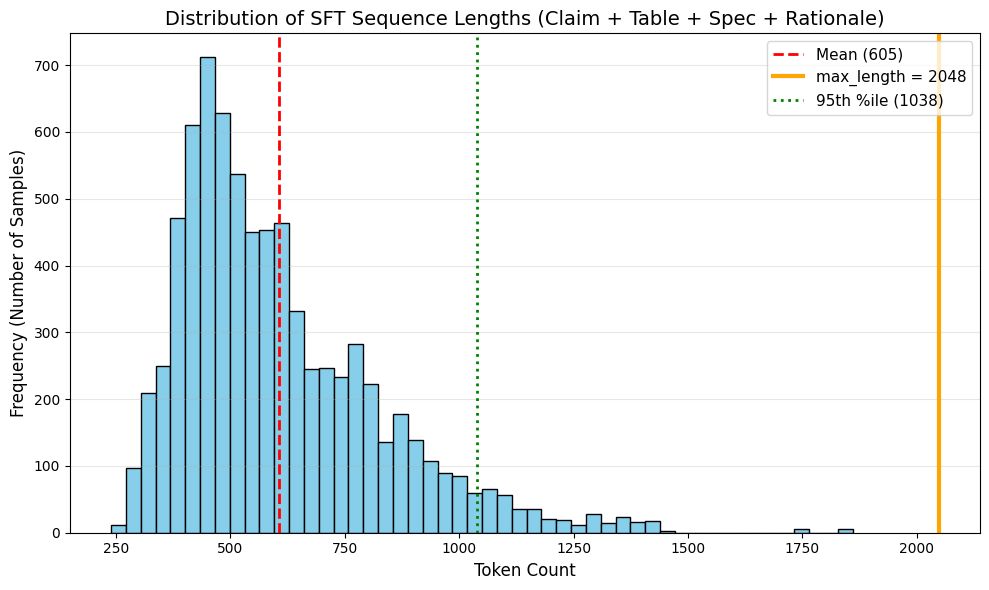

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

print("Analyzing token counts for the SFT training dataset...")
token_counts = []

for item in tqdm(train_dataset, desc="Calculating token lengths"):
    # Apply chat template first to get the actual formatted string,
    # then tokenize — this matches exactly what SFTTrainer will see
    formatted = tokenizer.apply_chat_template(
        item["messages"],
        tokenize=False,
        add_generation_prompt=False
    )
    tokens = tokenizer(formatted, truncation=False, add_special_tokens=False)
    token_counts.append(len(tokens["input_ids"]))

mean_len   = np.mean(token_counts)
median_len = np.median(token_counts)
max_len    = np.max(token_counts)
p90_len    = np.percentile(token_counts, 90)
p95_len    = np.percentile(token_counts, 95)
p99_len    = np.percentile(token_counts, 99)

print(f"\n{'='*40}")
print(f"📊 SFT Token Length Statistics")
print(f"{'='*40}")
print(f"Total Samples: {len(token_counts)}")
print(f"Mean Length:   {mean_len:.1f} tokens")
print(f"Median Length: {median_len:.1f} tokens")
print(f"Max Length:    {max_len} tokens")
print(f"90th %ile:     {p90_len:.0f} tokens")
print(f"95th %ile:     {p95_len:.0f} tokens")
print(f"99th %ile:     {p99_len:.0f} tokens")
print(f"{'-'*40}")
exceed_2048 = sum(1 for x in token_counts if x > 2048)
print(f"Samples > 2048 tokens: {exceed_2048} ({(exceed_2048/len(token_counts))*100:.2f}%)")
print(f"{'='*40}\n")

plt.figure(figsize=(10, 6))
plt.hist(token_counts, bins=50, color='skyblue', edgecolor='black')
plt.axvline(mean_len, color='red',    linestyle='dashed', linewidth=2, label=f'Mean ({mean_len:.0f})')
plt.axvline(2048,     color='orange', linestyle='solid',  linewidth=3, label='max_length = 2048')
plt.axvline(p95_len,  color='green',  linestyle='dotted', linewidth=2, label=f'95th %ile ({p95_len:.0f})')
plt.title("Distribution of SFT Sequence Lengths (Claim + Table + Spec + Rationale)", fontsize=14)
plt.xlabel("Token Count", fontsize=12)
plt.ylabel("Frequency (Number of Samples)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Model Loading (QLoRA Setup)

In [7]:
# 4-bit quantization config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16
)

model = prepare_model_for_kbit_training(model)

# --- FIX 2: Target MLP modules ---
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", 
                    "gate_proj", "up_proj", "down_proj"] 
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

trainable params: 29,933,568 || all params: 3,115,872,256 || trainable%: 0.9607


# SFT Training Execution

In [6]:
print(train_dataset[0].keys())

dict_keys(['claim', 'explanation', 'table', 'spec', 'title_description', 'text'])


In [9]:
from trl import SFTTrainer, SFTConfig
# from trl.trainer import DataCollatorForCompletionOnlyLM

# # --- FIX 1: Response Masking ---
# response_template = "<|im_start|>assistant\n"
# collator = DataCollatorForCompletionOnlyLM(response_template, tokenizer=tokenizer)

sft_config = SFTConfig(
    output_dir="/workspace/qwen-chart-sft",
    per_device_train_batch_size=4,      
    per_device_eval_batch_size=2,       
    gradient_accumulation_steps=4,      
    max_length=2048,
    
    # 🚀 THE NEW FIX: Native response masking
    completion_only_loss=True,
    
    save_strategy="steps",              
    save_steps=100,                     
    eval_strategy="steps",              
    eval_steps=100,
    save_total_limit=3,                 
    load_best_model_at_end=True,        
    
    optim="paged_adamw_32bit",
    learning_rate=5e-5,                 
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    logging_steps=10,
    num_train_epochs=4,                 
    
    bf16=True,                          
    report_to="none"
)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    # data_collator=collator, <-- REMOVE THIS LINE
    args=sft_config,
)

checkpoint_dir = "/workspace/qwen-chart-sft"
resume_from_checkpoint = True if os.path.exists(checkpoint_dir) and os.listdir(checkpoint_dir) else None

print(f"Starting SFT Training... (Resuming from: {resume_from_checkpoint})")
trainer.train(resume_from_checkpoint=resume_from_checkpoint)

trainer.model.save_pretrained("/workspace/qwen-chart-sft-final")
tokenizer.save_pretrained("/workspace/qwen-chart-sft-final")
print("Training complete and adapters saved!")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Tokenizing train dataset:   0%|          | 0/7607 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/7607 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/953 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/953 [00:00<?, ? examples/s]

Starting SFT Training... (Resuming from: None)


Step,Training Loss,Validation Loss
100,0.521257,0.542961
200,0.465582,0.529546
300,0.474822,0.518281
400,0.450825,0.503576
500,0.454798,0.488999
600,0.425654,0.470988
700,0.382083,0.453244
800,0.369970,0.436426
900,0.386015,0.420780
1000,0.343062,0.406205


Training complete and adapters saved!


## Generate SFT-Based Rationales

In [2]:
import os
import json
import torch
from tqdm.notebook import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

BASE_MODEL_ID = "Qwen/Qwen2.5-3B-Instruct" 
SFT_ADAPTER_PATH = "/workspace/qwen-chart-sft-final" 
CACHE_FILE = "grounding_cache.json"

BATCH_SIZE = 16

FILES_TO_PROCESS = {
    # "train_wo_spec.json": "train_with_SFT_rationales.json",
    # "validation_wo_spec.json": "val_with_SFT_rationales.json",
    "test_1_wo_spec.json" : "test_1_with_SFT_rationales.json",
    "test_2_wo_spec.json" : "test_2_with_SFT_rationales.json"
}

MAX_DESC_WORDS = 50

def generate_sft_rationales():
    print("Loading SFT Model...")
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID)
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left" 
    bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16)
    base_model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_ID, 
        quantization_config=bnb_config, 
        device_map="auto",
        attn_implementation="flash_attention_2"  # 🚀 THE FIX: Massive speedup for 5090
    )
    model = PeftModel.from_pretrained(base_model, SFT_ADAPTER_PATH)
    model.eval()

    cache = json.load(open(CACHE_FILE, 'r', encoding='utf-8'))

    for in_f, out_f in FILES_TO_PROCESS.items():
        if not os.path.exists(in_f):
            print(f"Skipping {in_f}, not found.")
            continue

        data = json.load(open(in_f, 'r', encoding='utf-8'))
        
        # Pre-filter valid data to make chunking cleaner
        valid_items = []
        for item in data:
            img_path = item.get("local_image_path", "").replace("\\\\", "/").replace("\\", "/")
            if img_path in cache and cache[img_path].get("deplot_table") and cache[img_path].get("vega_lite_spec"):
                item["img_path"] = img_path
                valid_items.append(item)

        results = []

        # 🚀 THE FIX: Process in chunks
        for i in tqdm(range(0, len(valid_items), BATCH_SIZE), desc=f"Processing {in_f}"):
            batch = valid_items[i : i + BATCH_SIZE]
            prompts = []

            for item in batch:
                table = cache[item["img_path"]]["deplot_table"]
                spec  = cache[item["img_path"]]["vega_lite_spec"]
                desc  = item.get("title_description", "")
                
                if desc:
                    words = desc.split()
                    if len(words) > MAX_DESC_WORDS:
                        desc = " ".join(words[:MAX_DESC_WORDS]) + "..."
                title_block = f"Chart Description:\n{desc}\n\n" if desc else ""

                user_content = (
                    f"{title_block}"
                    f"Claim: {item['claim']}\n\n"
                    f"Data Table:\n{table}\n\n"
                    f"Visual Spec:\n{spec}\n\n"
                    f"Verify if the claim is supported by the chart data. "
                    f"Think through the evidence first, then state your verdict. "
                    f"End your response with exactly 'Verdict: SUPPORTED' or 'Verdict: REFUTED'."
                )

                formatted_prompt = tokenizer.apply_chat_template(
                    [{"role": "user", "content": user_content}],
                    tokenize=False, add_generation_prompt=True
                )
                prompts.append(formatted_prompt)

            # Tokenize the whole batch at once
            inputs = tokenizer(prompts, return_tensors="pt", padding=True).to("cuda")

            with torch.no_grad():
                outputs = model.generate(
                    **inputs,
                    max_new_tokens=256,
                    do_sample=False,        
                    repetition_penalty=1.05,
                    pad_token_id=tokenizer.eos_token_id
                )

            # Slice out the prompt lengths and decode
            input_lengths = inputs.input_ids.shape[1]
            generated_texts = tokenizer.batch_decode(outputs[:, input_lengths:], skip_special_tokens=True)

            for item, gen_text in zip(batch, generated_texts):
                item["generated_rationale"] = gen_text
                results.append(item)

        with open(out_f, 'w', encoding='utf-8') as f:
            json.dump(results, f, indent=4)
        print(f"Saved {len(results)} items to {out_f}")

    del model, base_model
    torch.cuda.empty_cache()

generate_sft_rationales()

Loading SFT Model...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Processing test_1_wo_spec.json:   0%|          | 0/59 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Saved 939 items to test_1_with_SFT_rationales.json


Processing test_2_wo_spec.json:   0%|          | 0/62 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Analysis

In [1]:
import os
import json
import pandas as pd

# The files generated by your batched script
FILES_TO_CHECK = [
    "train_with_SFT_rationales.json",
    "val_with_SFT_rationales.json",
    "test_1_with_SFT_rationales.json",
    "test_2_with_SFT_rationales.json"
]

def analyze_empty_rationales():
    total_empty_across_all = 0
    total_items_across_all = 0
    
    for filepath in FILES_TO_CHECK:
        if not os.path.exists(filepath):
            print(f"Skipping {filepath} (File not found)")
            continue
            
        with open(filepath, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
        total_items = len(data)
        empty_items = []
        
        for item in data:
            rationale = str(item.get("generated_rationale", "")).strip()
            if not rationale:
                empty_items.append(item)
                
        empty_count = len(empty_items)
        total_empty_across_all += empty_count
        total_items_across_all += total_items
        
        print(f"\n{'='*60}")
        print(f"📄 File: {filepath}")
        print(f"{'='*60}")
        print(f"Total Items: {total_items}")
        print(f"Empty Rationales: {empty_count} ({(empty_count/total_items)*100:.2f}%)")
        
        # If there are empty rationales, do a quick pattern analysis
        if empty_count > 0:
            df_empty = pd.DataFrame(empty_items)
            
            print("\n  🔍 Analysis of Empty Generations:")
            if 'chart_type' in df_empty.columns:
                print("  By Chart Type:")
                print(df_empty['chart_type'].value_counts().to_string())
                
            print("\n  🚨 Sample Claims that resulted in Empty Rationales:")
            for idx, item in enumerate(empty_items[:3]): # Show up to 3 examples
                print(f"    {idx+1}. Image: {item.get('local_image_path', 'Unknown')}")
                print(f"       Claim: {item.get('claim', 'No claim text')}")
                
    print(f"\n{'*'*60}")
    if total_items_across_all > 0:
        overall_rate = (total_empty_across_all / total_items_across_all) * 100
        print(f"📊 OVERALL SYSTEM FAILURE RATE: {total_empty_across_all} / {total_items_across_all} ({overall_rate:.2f}%)")
    print(f"{'*'*60}")

analyze_empty_rationales()


📄 File: train_with_SFT_rationales.json
Total Items: 7607
Empty Rationales: 11 (0.14%)

  🔍 Analysis of Empty Generations:
  By Chart Type:
chart_type
line_chart             7
barchart_vertical      3
barchart_horizontal    1

  🚨 Sample Claims that resulted in Empty Rationales:
    1. Image: local_images/Question13ChartExport.jpg
       Claim: The responses to Question 13 are primarily related to images.
    2. Image: local_images\Slika2_spd.jpg
       Claim: Farm supplied by overhead lines accounted for 10 kV.
    3. Image: local_images/Question13ChartExport.jpg
       Claim: The claim that the chart shows the percentage of positive responses is false.

📄 File: val_with_SFT_rationales.json
Total Items: 953
Empty Rationales: 1 (0.10%)

  🔍 Analysis of Empty Generations:
  By Chart Type:
chart_type
line_chart    1

  🚨 Sample Claims that resulted in Empty Rationales:
    1. Image: local_images\Performance,2009-12-01.jpg
       Claim: Train performance is represented by a purple line on